In [114]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset
import os
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch.utils.data import Subset
import torch.optim as optim
import copy

In [115]:
# PARAMETERS

SEED = 42
TRAIN_VAL_SPLIT = 0.8
BATCH_SIZE = 128 #maybe try larger (64-128)
TRAINING_DATA_PERCENTAGE = 0.2
SMALLER_DATASET = True

In [116]:
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

random.seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

set_seed(SEED)

# os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # wymagane przez niektóre operacje CUDA
# device = torch.device("cuda")
device = torch.device("cpu")

In [117]:
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.files = [f for f in os.listdir(root_dir) if f != ".gitkeep"]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name = self.files[idx]
        img_path = os.path.join(self.root_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, img_name

Example test


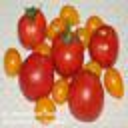

In [118]:
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.ImageFolder("train/")
testset = TestDataset("test/")

# map_class_to_idx = dataset_clean.class_to_idx  # map nazwy klasy na index
map_class_to_idx = trainset.class_to_idx  # map nazwy klasy na index
print('Example test')
testset[4][0].resize((128, 128)).show()

first train element: (<PIL.Image.Image image mode=RGB size=64x64 at 0x7B3FA53091E0>, 4)


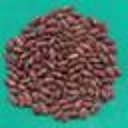

PIL -> Numpy: shape=(64, 64, 3) | dtype=uint8 | min=0 | max=220


In [119]:
sample = trainset[7777]
print("first train element:", sample)
sample[0].resize((128, 128)).show()
np_sample = np.array(sample[0])
print(
    f"PIL -> Numpy: shape={np_sample.shape} | dtype={np_sample.dtype} | min={np_sample.min()} | max={np_sample.max()}"
)

In [120]:
transform_to_tensor = transforms.Compose([transforms.ToTensor()])
full_dataset = torchvision.datasets.ImageFolder("train/", transform=transform_to_tensor)

train_size = int(TRAIN_VAL_SPLIT * len(full_dataset))
val_size = len(full_dataset) - train_size

trainset, validset = random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(SEED)
)

sample = trainset[4]
# img, label = sample

# plt.imshow(img.permute(1, 2, 0))  # CHW → HWC
# plt.title(label)
# plt.axis("off")
# plt.show()
print('przed skalowaniem')
print(
    f"PIL -> Tensor: shape={sample[0].shape} | dtype={sample[0].dtype} | min={sample[0].min()} | max={sample[0].max()}",
)


loader = DataLoader(trainset, batch_size=256, shuffle=False)

# global
sum_all = 0.0
sum_sq_all = 0.0
n_all = 0

# per channel
sum_c = 0.0
sum_sq_c = 0.0
n_c = 0

for images, _ in loader:
    b, c, h, w = images.shape

    # -------- GLOBAL --------
    sum_all += images.sum()
    sum_sq_all += (images ** 2).sum()
    n_all += images.numel()

    # -------- CHANNEL --------
    sum_c += images.sum(dim=(0, 2, 3))
    sum_sq_c += (images ** 2).sum(dim=(0, 2, 3))
    n_c += b * h * w


# GLOBAL stats
global_mean = sum_all / n_all
global_std = (sum_sq_all / n_all - global_mean**2).sqrt()

# CHANNEL stats
channel_mean = sum_c / n_c
channel_std = (sum_sq_c / n_c - channel_mean**2).sqrt()

stats = {"global_mean": global_mean, "global_std": global_std, "channel_mean": channel_mean, "channel_std": channel_std}
torch.save(stats, "norm_stats.pt")

print(f"Global: mean={global_mean:.4f} | std={global_std:.4f}")
print(f"Channel: mean={channel_mean} | std={channel_std}")

przed skalowaniem
PIL -> Tensor: shape=torch.Size([3, 64, 64]) | dtype=torch.float32 | min=0.0 | max=1.0
Global: mean=0.4849 | std=0.2884
Channel: mean=tensor([0.5209, 0.4955, 0.4384]) | std=tensor([0.2841, 0.2771, 0.2976])


In [121]:
stats = torch.load("norm_stats.pt")
mean = stats["channel_mean"]
std = stats["channel_std"]

train_transform = transforms.Compose([
    # possible augmentation
    # niezrownowazone klasy bread i carbon
    transforms.RandomApply(
        [
            transforms.CenterCrop(int(0.8*64)),
            transforms.Resize(64)
        ],
        p=0.5
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.25),
    transforms.RandomRotation(degrees=(-15, 15)),
    # transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)), # too strong
    transforms.GaussianBlur(kernel_size=(3), sigma=(0.1, 1)),
    # transforms.RandomInvert(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)]
)

test_transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize(mean, std)]
)

base_dataset = torchvision.datasets.ImageFolder("train/")
train_idx, val_idx = random_split(
    range(len(base_dataset)),
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)
trainset = Subset(
    torchvision.datasets.ImageFolder("train/", transform=train_transform), train_idx
)
if SMALLER_DATASET:
    n = len(trainset)
    k = int(TRAINING_DATA_PERCENTAGE * n)
    new_indices = torch.randperm(n)[:k]
    trainset_small = Subset(trainset, new_indices)
    trainset=trainset_small

validset = Subset(
    torchvision.datasets.ImageFolder("train/", transform=test_transform), val_idx
)
if SMALLER_DATASET:
    n = len(validset)
    k = int(TRAINING_DATA_PERCENTAGE * n)
    new_indices = torch.randperm(n)[:k]
    validset_small = Subset(validset, new_indices)
    validset = validset_small

testset = TestDataset("test/", transform=test_transform)

print('liczby przykladow ')
print('train dataset:', len(trainset))
print('validation dataset:', len(validset))
print('test dataset:', len(testset))

sample = trainset[4]

print('\npo skalowaniu')
print(
    f"PIL -> Tensor: shape={sample[0].shape} | dtype={sample[0].dtype} | min={sample[0].min()} | max={sample[0].max()}"
)


loader = DataLoader(trainset, batch_size=256, shuffle=False)

# global
sum_all = 0.0
sum_sq_all = 0.0
n_all = 0

# per channel
sum_c = 0.0
sum_sq_c = 0.0
n_c = 0

for images, _ in loader:
    b, c, h, w = images.shape

    # -------- GLOBAL --------
    sum_all += images.sum()
    sum_sq_all += (images**2).sum()
    n_all += images.numel()

    # -------- CHANNEL --------
    sum_c += images.sum(dim=(0, 2, 3))
    sum_sq_c += (images**2).sum(dim=(0, 2, 3))
    n_c += b * h * w


# GLOBAL stats
global_mean = sum_all / n_all
global_std = (sum_sq_all / n_all - global_mean**2).sqrt()

# CHANNEL stats
channel_mean = sum_c / n_c
channel_std = (sum_sq_c / n_c - channel_mean**2).sqrt()

print(f"Global: mean={global_mean:.4f} | std={global_std:.4f}")
print(f"Channel: mean={channel_mean} | std={channel_std}")

liczby przykladow 
train dataset: 14081
validation dataset: 3520
test dataset: 10000

po skalowaniu
PIL -> Tensor: shape=torch.Size([3, 64, 64]) | dtype=torch.float32 | min=-1.8336191177368164 | max=1.8872681856155396
Global: mean=-0.1144 | std=0.9863
Channel: mean=tensor([-0.1042, -0.1209, -0.1180]) | std=tensor([1.0006, 0.9895, 0.9685])


In [122]:
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=16
)
validloader = torch.utils.data.DataLoader(
    validset, batch_size=BATCH_SIZE, shuffle=False, num_workers=16
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=16
)

# get some random training images
images, labels = next(iter(trainloader))
images

tensor([[[[-1.4195, -1.4471, -1.4747,  ...,  0.8860,  0.2510, -0.5773],
          [-1.1710, -1.2124, -1.2400,  ...,  0.9274,  0.2648, -0.5635],
          [-0.9915, -1.0467, -1.0743,  ...,  0.9550,  0.2924, -0.5497],
          ...,
          [-1.1986, -0.7844, -0.4669,  ...,  0.9550,  0.9274,  0.8998],
          [-1.2262, -0.8396, -0.5359,  ...,  0.2786,  0.2510,  0.2372],
          [-1.2400, -0.8672, -0.5635,  ..., -0.5497, -0.5773, -0.5911]],

         [[-1.3496, -1.3779, -1.4062,  ...,  0.9999,  0.3488, -0.5004],
          [-1.0807, -1.1373, -1.1797,  ...,  1.0423,  0.3630, -0.4862],
          [-0.8967, -0.9533, -1.0099,  ...,  1.0707,  0.3913, -0.4721],
          ...,
          [-1.2080, -0.8259, -0.5287,  ...,  1.0423,  1.0423,  1.0423],
          [-1.1939, -0.8117, -0.5145,  ...,  0.3630,  0.3630,  0.3488],
          [-1.1939, -0.8117, -0.5004,  ..., -0.4862, -0.4862, -0.5004]],

         [[-1.1043, -1.1307, -1.1570,  ...,  1.2283,  0.5958, -0.2213],
          [-0.8803, -0.9198, -

In [123]:
print("[batch_size, channels, height, width]")
images[0:1].size()

[batch_size, channels, height, width]


torch.Size([1, 3, 64, 64])

In [124]:
# map_class_to_idx = trainset.class_to_idx  # map nazwy klasy na index
class_counts = {class_name: 0 for class_name in map_class_to_idx.keys()}
for _, label in trainset:
    # print(f"Image Label: {label}")
    class_counts[list(map_class_to_idx.keys())[list(map_class_to_idx.values()).index(label)]] += 1

# print('Liczba przykładów w każdej klasie:')
# class_counts

In [125]:
counts = torch.tensor(list(class_counts.values()))
# counts
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)  # normalizacja, aby śred
print('Wagi dla każdej klasy:')
weights

Wagi dla każdej klasy:


tensor([0.9944, 0.9558, 0.9836, 0.9980, 0.9836, 0.9492, 0.9459, 1.0167, 0.9361,
        0.9233, 1.5968, 1.0322, 0.9079, 2.9831, 0.8814, 0.9329, 0.8785, 0.9329,
        0.9109, 0.8430, 0.9393, 1.0167, 0.9265, 0.9980, 1.0481, 0.9525, 0.9592,
        0.8618, 0.9730, 0.9109, 0.9202, 1.0645, 0.8430, 1.0283, 0.8757, 0.9171,
        0.9265, 0.8701, 0.9171, 0.9525, 0.9492, 0.9426, 0.9109, 0.8536, 0.8959,
        0.9329, 0.9800, 1.0990, 1.0129, 0.9361])

In [ ]:
class Net(nn.Module):
    def __init__(self, act_fn):
        super().__init__()
        self.act_fn = act_fn

        self.block1=nn.Sequential(
            nn.Conv2d(3, 24, kernel_size=3, padding=1),
            nn.BatchNorm2d(24),
            act_fn,
            nn.MaxPool2d(2),
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(24, 48, kernel_size=3, padding=1),
            nn.BatchNorm2d(48),
            act_fn,
            nn.MaxPool2d(2),
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(48, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            act_fn,
            nn.MaxPool2d(2),
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(96, 96, kernel_size=3, padding=1),
            nn.BatchNorm2d(96),
            act_fn,
            nn.MaxPool2d(2),
        )

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        # !!!
        self.fc1 = nn.Linear(96, 50)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.avg_pool(x)
        x = torch.flatten(x, start_dim=1)
        # print('after flatten:', x.shape)
        # !!!
        x = self.dropout(x)
        x = self.fc1(x)
        return x
    
# wiecej epok 120->200 i pelny dataset

In [127]:
# MORE PARAMETERS

LR = 0.005
LOSS_FN = nn.CrossEntropyLoss(weight=weights)
OPTIMIZER = optim.AdamW
TRAIN_EPOCHS = 120
# REGULARIZATION = 'L2'
LAMBDA_REG = 3e-4
ACT_FN = nn.SiLU() # try wider or leakyrelu

In [128]:
set_seed(SEED)

criterion = LOSS_FN
net = Net(act_fn=ACT_FN).to(device)
optimizer = OPTIMIZER(net.parameters(), lr=LR)

total_params = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params}")

net

Trainable parameters: 141074


Net(
  (act_fn): SiLU()
  (block1): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(24, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  

In [129]:
def calc_accuracy(predictions: np.ndarray, targets: np.ndarray, n_classes=50):
    assert len(predictions) == len(targets)
    accuracies = []
    for i in range(n_classes):
        accuracies.append((predictions[targets == i] == i).sum() / (targets == i).sum())
    return np.mean(accuracies)

In [130]:
def evaluate_model(model, dataset, loss_module, acc_module=calc_accuracy):
    loader = DataLoader(
        dataset, batch_size=1000, shuffle=False, num_workers=16
    )
    model.eval()
    loss = 0
    n_samples = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in loader:
            y = y.view(-1, 1).float()
            preds = model(x)
            y = (
                y.squeeze().long()
            )  # CrossEntropyLoss expects class indices, not one-hot
            loss += loss_module(preds, y).item() * x.size(0)  # sum loss over batch
            n_samples += x.size(0)

            preds = torch.argmax(preds, dim=1)
            all_preds.append(preds.numpy())
            all_targets.append(y.numpy())

    loss = loss / n_samples if n_samples > 0 else 0

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    acc = acc_module(all_preds, all_targets)
    return loss, acc

In [ ]:
def train_model(
    model,
    train_dataset,
    valid_dataset,
    batch_size,
    num_epochs,
    loss_module,
    optimizer,
    lr,
    lambda_reg,
    verbose=0,
):
    def print_and_log(*args):
        txt = " ".join(str(arg) for arg in args)
        print(txt)
        with open("trainingresults.log", "a") as f:
            f.write(txt + "\n")

    with open("trainingresults.log", "a") as f:
        f.write(
            "\n\n" + "------------------------------------------------------" + "\n"
        )
    print_and_log("--- TRAINING FOR PARAMS ---")
    print_and_log(
        f"model architecture:",
        [len(p) for idx, p in enumerate(model.parameters()) if idx % 2 == 0],
    )
    if SMALLER_DATASET:
        print_and_log(f"{TRAINING_DATA_PERCENTAGE=}")
    else:
        print_and_log(f"Full dataset")
    print_and_log(f"{batch_size=}")
    print_and_log(f"{model.act_fn=}")
    print_and_log(f"{num_epochs=}")
    print_and_log(f"{lr=}")
    print_and_log(f"{lambda_reg=}")
    print_and_log("-----------")

    trainloader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=16
    )
    optimizer = optimizer(model.parameters(), lr=lr, weight_decay=lambda_reg)

    train_losses = []
    valid_losses = []
    valid_accuracies = []

    best_val_loss = float("inf")
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        n_samples = 0
        for x, y in trainloader:
            preds = model(x)
            y=y.long()
            # print(preds.shape, y.shape)
            loss = loss_module(preds, y)

            optimizer.zero_grad()
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * x.size(0)
            n_samples += x.size(0)

        train_loss = epoch_loss / n_samples
        # print(f"Epoch {epoch+1}/{num_epochs} | train_loss={train_loss:.4f}")
        train_losses.append(train_loss)
        val_loss, val_acc = evaluate_model(model, valid_dataset, loss_module)
        valid_losses.append(val_loss)
        valid_accuracies.append(val_acc)
        # print(f"Epoch {epoch+1}/{num_epochs} | val_loss={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())

        if verbose and (epoch + 1) % max(1, num_epochs // 20) == 0:
            print_and_log(
                f"Epoch {(epoch+1):02d}/{num_epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_acc={val_acc:.4f}"
            )

    # wczytanie najlepszego modelu
    model.load_state_dict(best_model_state)

    plt.figure(figsize=(8, 5))
    plt.plot(train_losses[0:], label="train") # possible cut for first epochs
    plt.plot(valid_losses[0:], label="valid")
    plt.legend()
    plt.title("Final training history")
    plt.show()

    return model, train_losses, valid_losses

--- TRAINING FOR PARAMS ---
model architecture: [24, 24, 48, 48, 96, 96, 96, 96, 50]
TRAINING_DATA_PERCENTAGE=0.2
batch_size=128
model.act_fn=SiLU()
num_epochs=120
lr=0.005
lambda_reg=0.0003
-----------
Epoch 06/120 | train_loss=3.0583 | val_loss=3.0348 | val_acc=0.1993
Epoch 12/120 | train_loss=2.8202 | val_loss=2.7982 | val_acc=0.2411
Epoch 18/120 | train_loss=2.6811 | val_loss=2.6350 | val_acc=0.2920
Epoch 24/120 | train_loss=2.5536 | val_loss=2.5554 | val_acc=0.3110
Epoch 30/120 | train_loss=2.4715 | val_loss=2.4804 | val_acc=0.3341
Epoch 36/120 | train_loss=2.4045 | val_loss=2.3566 | val_acc=0.3590
Epoch 42/120 | train_loss=2.3151 | val_loss=2.2944 | val_acc=0.3769
Epoch 48/120 | train_loss=2.2679 | val_loss=2.2618 | val_acc=0.3927
Epoch 54/120 | train_loss=2.2375 | val_loss=2.2563 | val_acc=0.4049
Epoch 60/120 | train_loss=2.2107 | val_loss=2.2356 | val_acc=0.3957
Epoch 66/120 | train_loss=2.1583 | val_loss=2.2158 | val_acc=0.4024
Epoch 72/120 | train_loss=2.1537 | val_loss=2.163

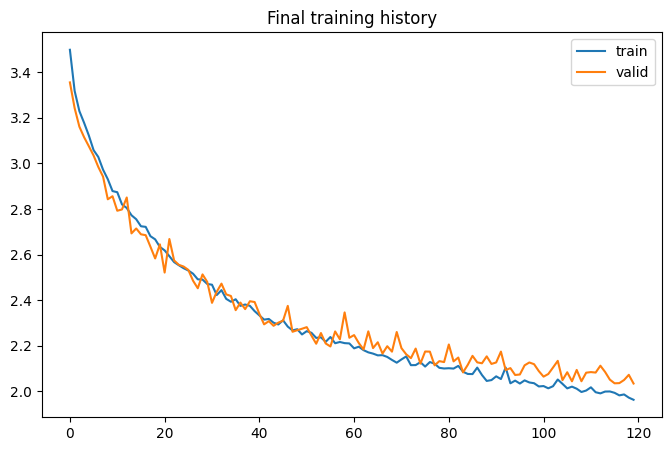

Best validation loss: 2.0349
Best validation balanced accuracy: 0.4493


In [132]:
net, train_losses, valid_losses = train_model(
    net,
    trainset,
    validset,
    batch_size=BATCH_SIZE,
    num_epochs=TRAIN_EPOCHS,
    loss_module=criterion,
    optimizer=OPTIMIZER,
    lr=LR,
    lambda_reg=LAMBDA_REG,
    # reg=REGULARIZATION,
    verbose=1,
)

best_val_results = evaluate_model(net, validset, criterion)
print(f"Best validation loss: {best_val_results[0]:.4f}")
print(f"Best validation balanced accuracy: {best_val_results[1]:.4f}")

In [139]:
print(len(trainset), len(validset), len(testset))

14081 3520 10000


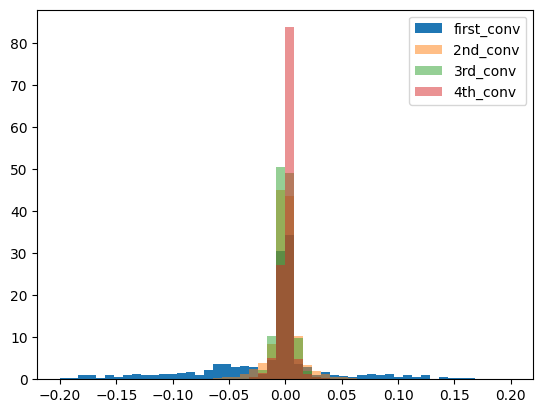

In [140]:
plt.hist(net.block1[0].weight.grad.cpu().detach().numpy().reshape(-1),bins=50, label="first_conv",density=True,range=[-0.2,0.2])
plt.hist(net.block2[0].weight.grad.cpu().detach().numpy().reshape(-1),bins=50, alpha=0.5, label="2nd_conv",density=True,range=[-0.2,0.2])
plt.hist(net.block3[0].weight.grad.cpu().detach().numpy().reshape(-1),bins=50, alpha=0.5, label="3rd_conv",density=True,range=[-0.2,0.2])
plt.hist(net.block4[0].weight.grad.cpu().detach().numpy().reshape(-1),bins=50, alpha=0.5, label="4th_conv",density=True,range=[-0.2,0.2])
plt.legend(loc='upper right')
plt.show()
plt.close()

In [ ]:
import pickle
import datetime
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
with open(f"model_state_{timestamp}.pkl", "wb") as f:
    pickle.dump(net.state_dict(), f)